### Scientific Visualization of Structural Properties

This notebook presents comparative scientific visualization of structural properties of h-BN and Silicon using Python libraries such as matplotlib and pandas.

The goal is to visually analyze:
- bond lengths
- density
- coordination behavior
- lattice parameters
- crystallographic differences

between the two crystalline materials.

In [1]:
from pymatgen.core.structure import Structure

In [2]:
hbn = Structure.from_file("..\\data\\h-BN.cif")

si = Structure.from_file("..\\data\\sillicon.cif")

c:\Users\Admin\anaconda3\Lib\site-packages\pymatgen\core\structure.py:3112: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [3]:
## import libraries for 

import matplotlib.pyplot as plt

In [4]:
## Bond length

hbn_bonds = hbn.get_distance(0, 2)

si_bonds = si.get_distance(0, 1)

print(f"hBN bond length: {hbn_bonds:.2f} Å")
print(f"Si bond length: {si_bonds:.2f} Å")

hBN bond length: 1.49 Å
Si bond length: 3.84 Å


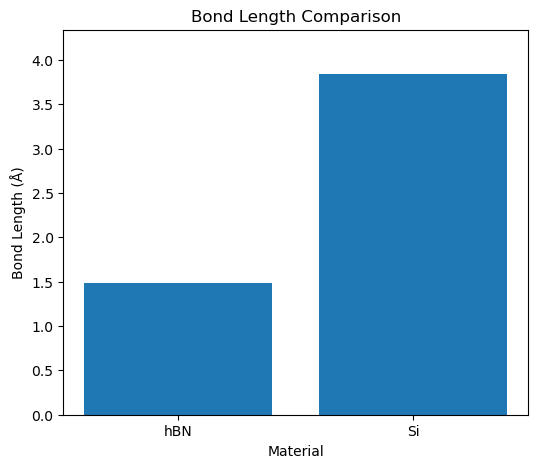

In [5]:
## visualize bond lengths

materials = ['hBN', 'Si']
bond_lengths = [hbn_bonds, si_bonds]

plt.figure(figsize=(6, 5))
plt.bar(materials, bond_lengths)



plt.title('Bond Length Comparison')
plt.xlabel('Material')
plt.ylabel('Bond Length (Å)')
plt.title('Bond Length Comparison')
plt.ylim(0, max(bond_lengths) + 0.5)
plt.show()

In [6]:
## Density

hbn_density = hbn.density
si_density = si.density

print(f"hBN density: {hbn_density:.2f} g/cm³")
print(f"Si density: {si_density:.2f} g/cm³")

hBN density: 2.26 g/cm³
Si density: 2.33 g/cm³


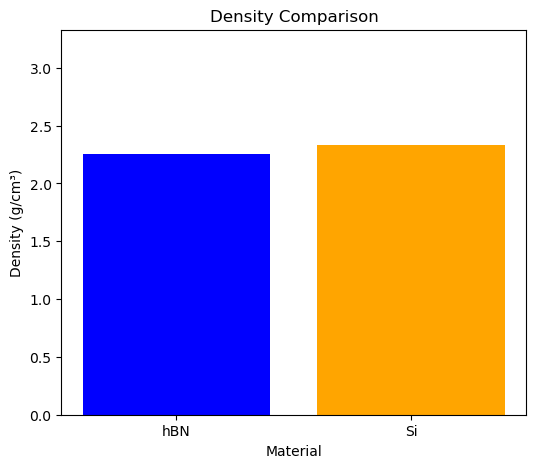

In [7]:
## visualize density

densities = [hbn_density, si_density]

plt.figure(figsize=(6, 5))

plt.bar(materials, densities, color=['blue', 'orange'])


plt.title('Density Comparison')
plt.xlabel('Material')
plt.ylabel('Density (g/cm³)')
plt.ylim(0, max(densities) + 1)
plt.show()

In [8]:
## lattice constants

hbn_lattice = hbn.lattice
si_lattice = si.lattice

print(f"hBN lattice constants: a={hbn_lattice.a:.2f} Å, b={hbn_lattice.b:.2f} Å, c={hbn_lattice.c:.2f} Å")
print(f"Si lattice constants: a={si_lattice.a:.2f} Å, b={si_lattice.b:.2f} Å, c={si_lattice.c:.2f} Å")

hBN lattice constants: a=2.51 Å, b=2.51 Å, c=6.69 Å
Si lattice constants: a=5.43 Å, b=5.43 Å, c=5.43 Å


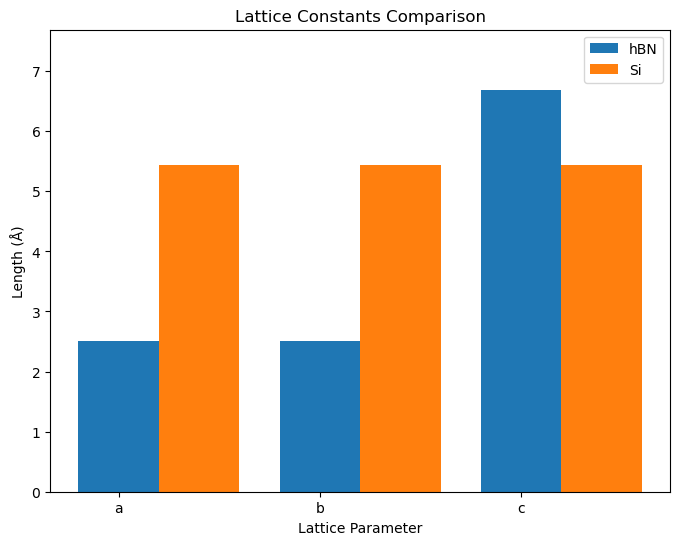

In [9]:
## visualize lattice constants

parameters = ['a', 'b', 'c']
hbn_values = [hbn_lattice.a, hbn_lattice.b, hbn_lattice.c]
si_values = [si_lattice.a, si_lattice.b, si_lattice.c]

x = range(len(parameters))

width = 0.4


plt.figure(figsize=(8, 6))

plt.bar(x, hbn_values, width=width, label='hBN')
plt.bar([i + width for i in x], si_values, width=width, label='Si') 

plt.xticks(x, parameters)
plt.title('Lattice Constants Comparison')
plt.xlabel('Lattice Parameter')
plt.ylabel('Length (Å)')
plt.legend()
plt.ylim(0, max(hbn_values + si_values) + 1)
plt.show()

In [10]:
##  Cordination number of hbn


hbn_neighbors = hbn.get_neighbors(hbn[0], 2.0)

hbn_coordination_number = len(hbn_neighbors)

## Coordination number of Si


si_neighbors = si.get_neighbors(si[0], 3.0)
si_coordination_number = len(si_neighbors)

print(f"hBN coordination number: {hbn_coordination_number}")
print(f"Si coordination number: {si_coordination_number}")


hBN coordination number: 6
Si coordination number: 4


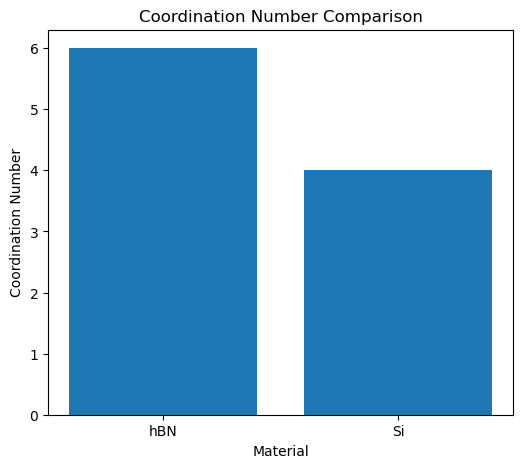

In [11]:
## plot coordination numbers

coordination_numbers = [hbn_coordination_number, si_coordination_number]

plt.figure(figsize=(6, 5))

plt.bar(materials, coordination_numbers)

plt.title('Coordination Number Comparison')
plt.xlabel('Material')
plt.ylabel('Coordination Number')
plt.show()

In [12]:
## crystal system analysis

from pymatgen.symmetry.analyzer import SpacegroupAnalyzer


hbn_sg = SpacegroupAnalyzer(hbn)
si_sg = SpacegroupAnalyzer(si)


print(f"hBN space group: {hbn_sg.get_space_group_symbol()} ({hbn_sg.get_space_group_number()})")
print(f"Si space group: {si_sg.get_space_group_symbol()} ({si_sg.get_space_group_number()})")

hBN space group: P-3m1 (164)
Si space group: Fd-3m (227)


In [13]:
print(hbn_sg.get_crystal_system())
print(si_sg.get_crystal_system())

trigonal
cubic
